<span style="font-size:2.5em"><strong>제2강 데이터수집 및 원시데이터 처리
</strong></span>

#### InteractiveShell의 모든 것을 출력하도록.

```
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'  #'last_expr'
```
또는

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%matplotlib inline 

### 파일 내용을 있는 그대로 읽어보는 Helper Function

In [2]:
def viewfile(filename, encoding='utf-8'):
    
    with open(filename, 'r', encoding=encoding) as f:
        while True:
            line = f.readline()
            if not line: break
            print(line, end='') 

### 사용할 데이터 파일 폴더 지정

In [3]:
Dataset_Path = ".\\data\\chp2\\" 

# 2.1 CSV 파일

### 기계가 읽을 수 있는 데이터(Machine-readable Data)
사람의 개입 없이 의미를 잃지 않으면서 컴퓨터가 쉽게 읽을 수 있는 형식의 데이터 (2019, OPEN Government Data Act)
- CSV
- JSON
- XML
- RDF  

### 인간이 읽을 수 있는 데이터(Human-readable Data)
- XLS (XLSX)
- PDF
- PPT

### CSV (Comma Separated Values)  파일 형식
- 레코드(열) 내의 각 필드가 콤마(쉼표)로 구분되어 있는 파일
- 각 레코드는 줄바꿈 문자로 구분
- 스프레드시트와 데이터베이스에서 가장 일반적인 가져오기 및 내보내기 형식
- 콤마 대신 탭(Tab)도 가능
- 확장자: `.csv`
- 엑셀에서 `.csv` 형식으로 읽고 저장 가능

### CSV 파일 읽기

In [4]:
viewfile(Dataset_Path + "data-text.csv")

"Indicator","PUBLISH STATES","Year","WHO region","World Bank income group","Country","Sex","Display Value","Numeric","Low","High","Comments"
"Life expectancy at birth (years)","Published","1990","Europe","High-income","Andorra","Both sexes","77","77.00000","","",""
"Life expectancy at birth (years)","Published","2000","Europe","High-income","Andorra","Both sexes","80","80.00000","","",""
"Life expectancy at age 60 (years)","Published","2012","Europe","High-income","Andorra","Female","28","28.00000","","",""
"Life expectancy at age 60 (years)","Published","2000","Europe","High-income","Andorra","Both sexes","23","23.00000","","",""
"Life expectancy at birth (years)","Published","2012","Eastern Mediterranean","High-income","United Arab Emirates","Female","78","78.00000","","",""
"Life expectancy at birth (years)","Published","2000","Americas","High-income","Antigua and Barbuda","Male","72","72.00000","","",""
"Life expectancy at age 60 (years)","Published","1990","Americas","High-income"

"Life expectancy at age 60 (years)","Published","1990","Europe","High-income","Malta","Male","18","18.00000","","",""
"Life expectancy at age 60 (years)","Published","2000","Europe","High-income","Malta","Male","20","20.00000","","",""
"Life expectancy at age 60 (years)","Published","2000","Europe","High-income","Malta","Both sexes","21","21.00000","","",""
"Life expectancy at birth (years)","Published","2012","Europe","High-income","Netherlands","Both sexes","81","81.00000","","",""
"Life expectancy at age 60 (years)","Published","1990","Europe","High-income","Netherlands","Both sexes","21","21.00000","","",""
"Life expectancy at birth (years)","Published","1990","Europe","High-income","Norway","Both sexes","77","77.00000","","",""
"Life expectancy at age 60 (years)","Published","1990","Europe","High-income","Norway","Female","23","23.00000","","",""
"Life expectancy at age 60 (years)","Published","1990","Europe","High-income","Norway","Both sexes","21","21.00000","","",""
"Life expec

"Healthy life expectancy (HALE) at birth (years)","Published","2012","Africa","Low-income","United Republic of Tanzania","Both sexes","52","52.00000","","",""
"Healthy life expectancy (HALE) at birth (years)","Published","2000","Europe","Lower-middle-income","Ukraine","Male","56","56.00000","","",""
"Healthy life expectancy (HALE) at birth (years)","Published","2000","Europe","Lower-middle-income","Ukraine","Female","65","65.00000","","",""
"Healthy life expectancy (HALE) at birth (years)","Published","2000","Americas","High-income","United States of America","Male","66","66.00000","","",""
"Healthy life expectancy (HALE) at birth (years)","Published","2012","Americas","High-income","United States of America","Both sexes","70","70.00000","","",""
"Healthy life expectancy (HALE) at birth (years)","Published","2000","Europe","Low-income","Uzbekistan","Male","56","56.00000","","",""
"Healthy life expectancy (HALE) at birth (years)","Published","2000","Europe","Low-income","Uzbekistan","Fe

In [5]:
# csv 파일을 line별로 list로 로드하여 5줄을 print해보기
import csv 
  
lines = []

with open(Dataset_Path + "data-text.csv", 'r') as f: 
    csvreader = csv.reader(f) # csv reader 객체 생성 
    for line in csvreader:
        lines.append(line)

for i in range(5):
    print(lines[i])

['Indicator', 'PUBLISH STATES', 'Year', 'WHO region', 'World Bank income group', 'Country', 'Sex', 'Display Value', 'Numeric', 'Low', 'High', 'Comments']
['Life expectancy at birth (years)', 'Published', '1990', 'Europe', 'High-income', 'Andorra', 'Both sexes', '77', '77.00000', '', '', '']
['Life expectancy at birth (years)', 'Published', '2000', 'Europe', 'High-income', 'Andorra', 'Both sexes', '80', '80.00000', '', '', '']
['Life expectancy at age 60 (years)', 'Published', '2012', 'Europe', 'High-income', 'Andorra', 'Female', '28', '28.00000', '', '', '']
['Life expectancy at age 60 (years)', 'Published', '2000', 'Europe', 'High-income', 'Andorra', 'Both sexes', '23', '23.00000', '', '', '']


### 문제-1 위 cell의 코드를 효율적으로 고치고자 한다. 빈 칸을 채우시오.
* 밑줄 표시된 빈 칸의 코드를 완성하여 아래와 같은 출력이 나오도록 할 것.
* [힌트] zip() 함수를 사용할 것. 5줄만 출력하는 것임.

```
import csv 
  
with open(Dataset_Path + "data-text.csv", 'r') as f: 
    # csv reader 객체 생성 
    csvreader = csv.reader(f)
    
    for ________ in ________:
        print(________)
```

In [ ]:
'''예상 출력
['Indicator', 'PUBLISH STATES', 'Year', 'WHO region', 'Country', 'Sex', 'Display Value', 'Numeric', 'Low', 'High', 'Comments']
['Life expectancy at birth (years)', 'Published', '2000', 'Africa', 'Rwanda', 'Male', '43.0', '42.99474', '', '', '']
['Life expectancy at age 60 (years)', 'Published', '2000', 'Africa', 'Rwanda', 'Male', '13.4', '13.37898', '', '', '']
['Life expectancy at birth (years)', 'Published', '2000', 'Africa', 'Rwanda', 'Female', '48.4', '48.38779', '', '', '']
['Life expectancy at age 60 (years)', 'Published', '2000', 'Africa', 'Rwanda', 'Female', '14.9', '14.92907', '', '', '']
'''

### 문제-1 정답

In [6]:
import csv 
  
# csv 파일 읽기 
with open(Dataset_Path + "data-text.csv", 'r') as f: 
    # csv reader 객체 생성 
    csvreader = csv.reader(f)
    
    for _, (_, line) in zip(range(5), enumerate(csvreader)):
        print(line)

['Indicator', 'PUBLISH STATES', 'Year', 'WHO region', 'World Bank income group', 'Country', 'Sex', 'Display Value', 'Numeric', 'Low', 'High', 'Comments']
['Life expectancy at birth (years)', 'Published', '1990', 'Europe', 'High-income', 'Andorra', 'Both sexes', '77', '77.00000', '', '', '']
['Life expectancy at birth (years)', 'Published', '2000', 'Europe', 'High-income', 'Andorra', 'Both sexes', '80', '80.00000', '', '', '']
['Life expectancy at age 60 (years)', 'Published', '2012', 'Europe', 'High-income', 'Andorra', 'Female', '28', '28.00000', '', '', '']
['Life expectancy at age 60 (years)', 'Published', '2000', 'Europe', 'High-income', 'Andorra', 'Both sexes', '23', '23.00000', '', '', '']


### CSV 파일 쓰기

In [13]:
import csv 
  
fields = ['Name', 'Age', 'Gender', 'Hight', 'Home'] 
  
lines = [['김명호', '22', '남', '172', '서울시 중구'], 
         ['박소연', '18', '여', '162', '경기도 성남시'], 
         ['이명숙', '26', '여', '164', '경기도 하남시'], 
         ['최병서', '33', '남', '182', '서울시 서대문구']]
         
with open(Dataset_Path + "member.csv", 'w', encoding='utf-8') as f: 
    
    writer = csv.writer(f)  # csv writer 객체 생성 
      
    # 필드명 쓰기
    writer.writerow(fields) 
      
    # 나머지 데이터 모두 쓰기 
    writer.writerows(lines)

In [15]:
viewfile(Dataset_Path + "member.csv")

Name,Age,Gender,Hight,Home

김명호,22,남,172,서울시 중구

박소연,18,여,162,경기도 성남시

이명숙,26,여,164,경기도 하남시

최병서,33,남,182,서울시 서대문구



* utf-8 codec 오류 수정

In [16]:
import csv 
  
fields = ['Name', 'Age', 'Gender', 'Hight', 'Home'] 
  
lines = [['김명호', '22', '남', '172', '서울시 중구'], 
         ['박소연', '18', '여', '162', '경기도 성남시'], 
         ['이명숙', '26', '여', '164', '경기도 하남시'], 
         ['최병서', '33', '남', '182', '서울시 서대문구']]
         
with open(Dataset_Path + "member.csv", 'w', encoding='utf-8') as f: 
    
    writer = csv.writer(f)  # csv writer 객체 생성 
      
    # 필드명 쓰기
    writer.writerow(fields) 
      
    # 나머지 데이터 모두 쓰기 
    writer.writerows(lines)

viewfile(Dataset_Path + "member.csv")

Name,Age,Gender,Hight,Home

김명호,22,남,172,서울시 중구

박소연,18,여,162,경기도 성남시

이명숙,26,여,164,경기도 하남시

최병서,33,남,182,서울시 서대문구



### [문제-2] 줄 사이 빈칸 없애기
* viewfile 실행 결과를 보면 레코드 사이에 빈 줄이 나온다. 이 빈줄을 없애도록 위의 코드를 수정하시오.

#### [문제-2] 정답

In [17]:
import csv 
  
fields = ['Name', 'Age', 'Gender', 'Hight', 'Home'] 
  
lines = [['김명호', '22', '남', '172', '서울시 중구'], 
         ['박소연', '18', '여', '162', '경기도 성남시'], 
         ['이명숙', '26', '여', '164', '경기도 하남시'], 
         ['최병서', '33', '남', '182', '서울시 서대문구']]
         
with open(Dataset_Path + "member.csv", 'w', encoding='utf-8', newline='') as f: 
    
    writer = csv.writer(f)  # csv writer 객체 생성 
      
    # 필드명 쓰기
    writer.writerow(fields) 
      
    # 나머지 데이터 모두 쓰기 
    writer.writerows(lines)

viewfile(Dataset_Path + "member.csv")

Name,Age,Gender,Hight,Home
김명호,22,남,172,서울시 중구
박소연,18,여,162,경기도 성남시
이명숙,26,여,164,경기도 하남시
최병서,33,남,182,서울시 서대문구


### Dictionary 데이터를 CSV 파일에 write하기 

In [14]:
import csv 
      
fields = ['Name', 'Age', 'Gender', 'Hight', 'Home'] 
  
dict_data = [{'Name':'김명호', 'Age':'22', 'Gender':'남', 'Hight':'172', 'Home':'서울시 중구'}, 
             {'Name':'박소연', 'Age':'18', 'Gender':'여', 'Hight':'162', 'Home':'경기도 성남시'}, 
             {'Name':'이명숙', 'Age':'26', 'Gender':'여', 'Hight':'164', 'Home':'경기도 하남시'}, 
             {'Name':'최병서', 'Age':'33', 'Gender':'남', 'Hight':'182', 'Home':'서울시 서대문구'}]
         
with open(Dataset_Path + "member_dict.csv", 'w', encoding='utf-8', newline='') as f: 
    
    writer = csv.DictWriter(f, fieldnames=fields)  # Dictionary writer 객체 생성 

    writer.writeheader()
    
    for data in dict_data:
        writer.writerow(data)

viewfile(Dataset_Path + "member_dict.csv")

Name,Age,Gender,Hight,Home
김명호,22,남,172,서울시 중구
박소연,18,여,162,경기도 성남시
이명숙,26,여,164,경기도 하남시
최병서,33,남,182,서울시 서대문구


### CSV 파일을 Dictionary로 읽어들이기

In [22]:
import csv

dict_list = []

with open(Dataset_Path + "member_dict.csv", 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f, fieldnames = fields)
    for i, row in enumerate(reader):
        if i == 0: continue
        dict_list.append(dict(row))

dict_list

[{'Name': '김명호', 'Age': '22', 'Gender': '남', 'Hight': '172', 'Home': '서울시 중구'},
 {'Name': '박소연',
  'Age': '18',
  'Gender': '여',
  'Hight': '162',
  'Home': '경기도 성남시'},
 {'Name': '이명숙',
  'Age': '26',
  'Gender': '여',
  'Hight': '164',
  'Home': '경기도 하남시'},
 {'Name': '최병서',
  'Age': '33',
  'Gender': '남',
  'Hight': '182',
  'Home': '서울시 서대문구'}]

In [16]:
row

OrderedDict([('Name', '최병서'),
             ('Age', '33'),
             ('Gender', '남'),
             ('Hight', '182'),
             ('Home', '서울시 서대문구')])

* `collections.OrderedDict`: 입력 순서대로 읽을 수 있음. 파이썬 3.6 부터는 기본 사전(dict)도 OrderedDict 클래스와 동일하게 동작.

In [27]:
print(row)
list(row.items())[4][1]

{'Name': '최병서', 'Age': '33', 'Gender': '남', 'Hight': '182', 'Home': '서울시 서대문구'}


'서울시 서대문구'

###  Pandas로 CSV 파일 읽기 & 쓰기

In [28]:
import pandas as pd

# 읽기
data = pd.read_csv(Dataset_Path + "member.csv", encoding='utf-8')

type(data)

pandas.core.frame.DataFrame

In [29]:
# 앞 5 줄 보기
data.head()

,Name,Age,Gender,Hight,Home
0,김명호,22,남,172,서울시 중구
1,박소연,18,여,162,경기도 성남시
2,이명숙,26,여,164,경기도 하남시
3,최병서,33,남,182,서울시 서대문구


In [30]:
# 파일에 쓰기
data.to_csv(Dataset_Path + "new_data.csv", encoding='utf-8', sep=",", index=False)

viewfile(Dataset_Path + "new_data.csv")

Name,Age,Gender,Hight,Home
김명호,22,남,172,서울시 중구
박소연,18,여,162,경기도 성남시
이명숙,26,여,164,경기도 하남시
최병서,33,남,182,서울시 서대문구


# 2.2 JSON 파일 
## JSON (JavaScript Object Notation) 파일 형식

- 데이터 전송을 위해 가장 흔히 쓰이는 개방형 표준 형식
- 데이터 객체를 전달하기 위해 인간이 읽을 수 있는 데이터(텍스트)를 사용
- 속성-값 쌍(attribute-value pair) 또는 키-값 쌍(key-value pair)으로 이루어짐
- XML을 대체하는 주요 데이터 형식
- 웹사이트에서 JavaScript로 자료를 전송하는 데에 자주 사용됨
- 자료의 종류에 큰 제한이 없다
- 컴퓨터 프로그램의 변수값을 표현하는 데 적합
- Python dictionary 스타일의 구조를 가지므로 다루기 편함

## JSON의 기본 자료형
- 수(Number)
- 문자열(String)
  - 0 개 이상의 유니코드 문자들의 연속
  - 문자열은 큰 따옴표(")로 구분
  - 역슬래시('\\') 이스케이프 문법(escaping syntax)을 지원한다.
- 참/거짓(Boolean)
  - true 또는 false 값
- 배열(Array)
  - 0 개 이상의 임의의 종류의 값으로 이루어진 순서가 있는 리스트
  - 대괄호로 나타내며 요소는 쉼표로 구분한다.
- 객체(Object)
  - 순서가 없는 키-값 쌍의 집합으로, 키(이름)은 문자열이다.
- null
  - 누락값으로 null을 사용한다.

### JSON 파일 예시
```
{
  "firstName": "John",
  "lastName": "Smith",
  "isAlive": true,
  "age": 27,
  "address": {
    "streetAddress": "21 2nd Street",
    "city": "New York",
    "state": "NY",
    "postalCode": "10021-3100"
  },
  "phoneNumbers": [
    {
      "type": "home",
      "number": "212 555-1234"
    },
    {
      "type": "office",
      "number": "646 555-4567"
    },
    {
      "type": "mobile",
      "number": "123 456-7890"
    }
  ],
  "children": [],
  "spouse": null
}
![image.png](attachment:image.png)
```

In [31]:
viewfile(Dataset_Path + "member.json")

[
    {
        "Name": "김명호",
        "Age": 22,
        "Gender": "남",
        "Hight": 172,
        "Home": "서울시 중구"
    },
    {
        "Name": "박소연",
        "Age": 18,
        "Gender": "여",
        "Hight": 162,
        "Home": "경기도 성남시"
    },
    {
        "Name": "이명숙",
        "Age": 26,
        "Gender": "여",
        "Hight": 164,
        "Home": "경기도 하남시"
    },
    {
        "Name": "최병서",
        "Age": 33,
        "Gender": "남",
        "Hight": 182,
        "Home": "서울시 서대문구"
    }
]

## JSON file to Dictionary

In [32]:
import json 
  
with open(Dataset_Path + "member.json", 'r', encoding='utf-8') as f:
    data_dict = json.load(f)
    
data_dict

[{'Name': '김명호', 'Age': 22, 'Gender': '남', 'Hight': 172, 'Home': '서울시 중구'},
 {'Name': '박소연', 'Age': 18, 'Gender': '여', 'Hight': 162, 'Home': '경기도 성남시'},
 {'Name': '이명숙', 'Age': 26, 'Gender': '여', 'Hight': 164, 'Home': '경기도 하남시'},
 {'Name': '최병서', 'Age': 33, 'Gender': '남', 'Hight': 182, 'Home': '서울시 서대문구'}]

## Pandas에서 JSON 파일 읽기

In [33]:
import pandas as pd

# We can do the same thing with pandas
data_df = pd.read_json(Dataset_Path + "member.json", orient='records')
data_df

,Name,Age,Gender,Hight,Home
0,김명호,22,남,172,서울시 중구
1,박소연,18,여,162,경기도 성남시
2,이명숙,26,여,164,경기도 하남시
3,최병서,33,남,182,서울시 서대문구


## Dictionary 또는 DataFrame에서 JSON 파일 쓰기

In [39]:
import pandas as pd
import json

with open(Dataset_Path + "member_1.json", 'w', encoding='utf-8-sig') as f:
    json.dump(data_dict, f, indent=4, ensure_ascii=False, sort_keys=True)

export = data_df.to_json(Dataset_Path + "member_2.json", orient='records')
    
viewfile(Dataset_Path + "member_1.json")

﻿[
    {
        "Age": 22,
        "Gender": "남",
        "Hight": 172,
        "Home": "서울시 중구",
        "Name": "김명호"
    },
    {
        "Age": 18,
        "Gender": "여",
        "Hight": 162,
        "Home": "경기도 성남시",
        "Name": "박소연"
    },
    {
        "Age": 26,
        "Gender": "여",
        "Hight": 164,
        "Home": "경기도 하남시",
        "Name": "이명숙"
    },
    {
        "Age": 33,
        "Gender": "남",
        "Hight": 182,
        "Home": "서울시 서대문구",
        "Name": "최병서"
    }
]

- 'utf-8-sig'에서 'sig'는 'signature'의 약칭.
- 'utf-8-sig'를 사용하면 스트링 즉, 문자열로 처리하는게 아니라 Byte Order Mark(BOM)으로 취급함.

In [40]:
viewfile(Dataset_Path + "member_2.json")

[{"Name":"\uae40\uba85\ud638","Age":22,"Gender":"\ub0a8","Hight":172,"Home":"\uc11c\uc6b8\uc2dc \uc911\uad6c"},{"Name":"\ubc15\uc18c\uc5f0","Age":18,"Gender":"\uc5ec","Hight":162,"Home":"\uacbd\uae30\ub3c4 \uc131\ub0a8\uc2dc"},{"Name":"\uc774\uba85\uc219","Age":26,"Gender":"\uc5ec","Hight":164,"Home":"\uacbd\uae30\ub3c4 \ud558\ub0a8\uc2dc"},{"Name":"\ucd5c\ubcd1\uc11c","Age":33,"Gender":"\ub0a8","Hight":182,"Home":"\uc11c\uc6b8\uc2dc \uc11c\ub300\ubb38\uad6c"}]

## JSON 파일을 읽어서 CSV 파일로 쓰기

In [41]:
import json
import pandas as pd
import csv

with open(Dataset_Path + 'member.json', encoding='utf-8' ) as f:
    data_dict = json.load(f)
    
# Writing a list of dicts to CSV
keys = data_dict[0].keys()
with open(Dataset_Path + 'member_3.csv', 'w', encoding='utf-8', newline='') as f:
    dict_writer = csv.DictWriter(f, keys)
    dict_writer.writeheader()
    dict_writer.writerows(data_dict)

viewfile(Dataset_Path + 'member_3.csv')

Name,Age,Gender,Hight,Home
김명호,22,남,172,서울시 중구
박소연,18,여,162,경기도 성남시
이명숙,26,여,164,경기도 하남시
최병서,33,남,182,서울시 서대문구


# 2.3 XML 파일 
## 마크업 언어 (Markup Language)
### 형식
- 태그 등을 이용하여 문서나 데이터의 구조를 명기하는 언어의 한가지로서, 태그 방법의 체계를 마크업 언어라 한다.
- 원래 원고의 교정부호와 주석을 표현하던 용도에서 확장된 것

### 마크업 언어 분류 
- 표현적 마크업(Presentational markup): 전통적 워드 프로세싱 시스템이 사용하는 마크업. WYSIWYG 효과를 내도록 문서에 포함되어 사용자 눈에 보이지 않도록 설계된다.
- 절차적 마크업(Procedural markup): 문서에 포함되어 처리할 프로그램의 명령을 제공
  - [예] LaTeX, PostScript, troff 등
- 기술적 마크업(Descriptive markup): 문서의 논리적 구조 및 속성을 표현한다.
  - [예] SGML, HTML, XML


### 마크업 언어의 예: HTML (HyperText Markup Language)
- 웹페이지를 위한 지배적인 마크업 언어
- 제목, 단락, 목록 등과 같은 본문을 위한 구조적 의미를 나타내는 것뿐만 아니라 링크, 인용과 그 밖의 항목으로 구조적 문서를 만들 수 있는 방법을 제공한다.
- HTML에서의 프로그램: Hello World!
  
```  
<!doctype html>
<html>
  <head>
    <title>Hello HTML</title>
  </head>
  <body>
    <p>Hello World!</p>
  </body>
</html>
```

- 요소(Elements)
  - 시작 태그start tag <태그명> 과 종료 태그end tag </태그명> 및 두 태그 사이의 내용
  - HTML 요소Element의 보편적 형태: 
```
    <tag attribute1="value1" attribute2="value2">보이는 내용</tag> 
```

## XML (Extensible Markup Language)
### 개요
- 여러 특수 목적의 마크업 언어를 만드는 용도로 권장되는 다목적 마크업 언어로서 W3C에서 개발된 개방형 표준
- HTML과 달리 웹상에서 구조화된 문서를 전송가능하도록 설계됨
- 데이터에 의미를 부여하는 메타데이터를 기술할 수 있음
  - [예] “CPU 2.83GHz”:
     - HTML: 데이터 명과 실제 데이터 구분 표시가 불가능
     - XML: <dataname>CPU</dataname>과 <datavalue>2.83</datavalue>로 구분 가능
  

### 용어
- (유니코드) 문자: 거의 모든 올바른 유니코드 문자는 XML 문서에 나타날 수 있다.
- 프로세서와 애플리케이션: 프로세서(XML Parser라고 함)는 마크업을 분석하고 구조화된 정보를 애플리케이션에 넘긴다. 

- 마크업과 내용
  - 마크업: `<` 과 `>` 쌍, `&` 과 `;` 쌍, `<![CDATA[` 과 `]]>` 쌍, 가장 바깥 요소의 앞과 뒤의 공백.
  - 내용: 마크업이 아닌 문자열
- 태그
  - 시작 태그: (예) ```<section>```
  - 종료 태그: (예) ```</section>```
  - 빈 요소(empty-element) 태그: (예) ```<line-break/>```
- 요소
  - 시작 태그start tag <태그명> 과 종료 태그end tag </태그명> 및 두 태그 사이의 내용
  - 빈 요소 태그
  - 시작 태그와 종료 태그 사이의 내용은 다른 자식 요소를 포함할 수 있다.
- 속성attribute
  - 이름/값 짝으로 이루어진 마크업 구조로 시작 태그 또는 빈 엘리먼트 태그 속에 위치한다.
  - (예) ```<img src="madonna.jpg" alt='Foligno Madonna, by Raphael'/>``` 에서 img는 src와 alt의 두 속성을 갖는다.

## JSON 파일을 읽어서 XML 파일로 쓰기

!conda install dicttoxml

In [43]:
import json
from dicttoxml import dicttoxml

with open(Dataset_Path + 'member.json', 'r', encoding='utf-8') as f:
    data_dict = json.load(f)
    
data_xml = dicttoxml(data_dict).decode()

with open(Dataset_Path + 'member_3.xml', 'w', encoding='utf-8') as f:
    f.write(data_xml)

viewfile(Dataset_Path + 'member_3.xml')

<?xml version="1.0" encoding="UTF-8" ?><root><item type="dict"><Name type="str">김명호</Name><Age type="int">22</Age><Gender type="str">남</Gender><Hight type="int">172</Hight><Home type="str">서울시 중구</Home></item><item type="dict"><Name type="str">박소연</Name><Age type="int">18</Age><Gender type="str">여</Gender><Hight type="int">162</Hight><Home type="str">경기도 성남시</Home></item><item type="dict"><Name type="str">이명숙</Name><Age type="int">26</Age><Gender type="str">여</Gender><Hight type="int">164</Hight><Home type="str">경기도 하남시</Home></item><item type="dict"><Name type="str">최병서</Name><Age type="int">33</Age><Gender type="str">남</Gender><Hight type="int">182</Hight><Home type="str">서울시 서대문구</Home></item></root>

## JSON 파일을 읽어서 XML 파일로 쓰기(보기 좋게)

In [44]:
import json
from dicttoxml import dicttoxml
from xml.dom.minidom import parseString
# dom: Document Object Model

with open(Dataset_Path + 'member.json', 'r', encoding='utf-8') as f:
    data_dict = json.load(f)
    
data_xml = dicttoxml(data_dict).decode()
dom = parseString(data_xml)

with open(Dataset_Path + 'member_3.xml', 'w', encoding='utf-8') as f:
    f.write(dom.toprettyxml())

viewfile(Dataset_Path + 'member_3.xml')

<?xml version="1.0" ?>
<root>
	<item type="dict">
		<Name type="str">김명호</Name>
		<Age type="int">22</Age>
		<Gender type="str">남</Gender>
		<Hight type="int">172</Hight>
		<Home type="str">서울시 중구</Home>
	</item>
	<item type="dict">
		<Name type="str">박소연</Name>
		<Age type="int">18</Age>
		<Gender type="str">여</Gender>
		<Hight type="int">162</Hight>
		<Home type="str">경기도 성남시</Home>
	</item>
	<item type="dict">
		<Name type="str">이명숙</Name>
		<Age type="int">26</Age>
		<Gender type="str">여</Gender>
		<Hight type="int">164</Hight>
		<Home type="str">경기도 하남시</Home>
	</item>
	<item type="dict">
		<Name type="str">최병서</Name>
		<Age type="int">33</Age>
		<Gender type="str">남</Gender>
		<Hight type="int">182</Hight>
		<Home type="str">서울시 서대문구</Home>
	</item>
</root>


## 속성(Attribute) 없애기

In [45]:
import json
from dicttoxml import dicttoxml
from xml.dom.minidom import parseString

with open(Dataset_Path + 'member.json', 'r', encoding='utf-8') as f:
    data_dict = json.load(f)
    
data_xml = dicttoxml(data_dict, attr_type=False).decode()
dom = parseString(data_xml)

with open(Dataset_Path + 'member_3.xml', 'w', encoding='utf-8') as f:
    f.write(dom.toprettyxml())

viewfile(Dataset_Path + 'member_3.xml')

<?xml version="1.0" ?>
<root>
	<item>
		<Name>김명호</Name>
		<Age>22</Age>
		<Gender>남</Gender>
		<Hight>172</Hight>
		<Home>서울시 중구</Home>
	</item>
	<item>
		<Name>박소연</Name>
		<Age>18</Age>
		<Gender>여</Gender>
		<Hight>162</Hight>
		<Home>경기도 성남시</Home>
	</item>
	<item>
		<Name>이명숙</Name>
		<Age>26</Age>
		<Gender>여</Gender>
		<Hight>164</Hight>
		<Home>경기도 하남시</Home>
	</item>
	<item>
		<Name>최병서</Name>
		<Age>33</Age>
		<Gender>남</Gender>
		<Hight>182</Hight>
		<Home>서울시 서대문구</Home>
	</item>
</root>


##  ROOT 이름 바꾸기

In [46]:
import json
from dicttoxml import dicttoxml
from xml.dom.minidom import parseString

with open(Dataset_Path + 'member.json', 'r', encoding='utf-8') as f:
    data_dict = json.load(f)
    
data_xml = dicttoxml(data_dict, custom_root='member', attr_type=False).decode()
dom = parseString(data_xml)

with open(Dataset_Path + 'member_3.xml', 'w', encoding='utf-8') as f:
    f.write(dom.toprettyxml())

viewfile(Dataset_Path + 'member_3.xml')

<?xml version="1.0" ?>
<member>
	<item>
		<Name>김명호</Name>
		<Age>22</Age>
		<Gender>남</Gender>
		<Hight>172</Hight>
		<Home>서울시 중구</Home>
	</item>
	<item>
		<Name>박소연</Name>
		<Age>18</Age>
		<Gender>여</Gender>
		<Hight>162</Hight>
		<Home>경기도 성남시</Home>
	</item>
	<item>
		<Name>이명숙</Name>
		<Age>26</Age>
		<Gender>여</Gender>
		<Hight>164</Hight>
		<Home>경기도 하남시</Home>
	</item>
	<item>
		<Name>최병서</Name>
		<Age>33</Age>
		<Gender>남</Gender>
		<Hight>182</Hight>
		<Home>서울시 서대문구</Home>
	</item>
</member>


## XML Parsing

In [47]:
viewfile(Dataset_Path + 'xml-parsing.xml')

<?xml version="1.0"?>
<data>
    <country name="Liechtenstein">
        <rank>1</rank>
        <year>2008</year>
        <gdppc>141100</gdppc>
        <neighbor name="Austria" direction="E"/>
        <neighbor name="Switzerland" direction="W"/>
    </country>
    <country name="Singapore">
        <rank>4</rank>
        <year>2011</year>
        <gdppc>59900</gdppc>
        <neighbor name="Malaysia" direction="N"/>
    </country>
    <country name="Panama">
        <rank>68</rank>
        <year>2011</year>
        <gdppc>13600</gdppc>
        <neighbor name="Costa Rica" direction="W"/>
        <neighbor name="Colombia" direction="E"/>
    </country>
</data>

### XML 파일 로드

In [49]:
import xml.etree.ElementTree as ET

# parse xml file
doc = ET.parse(Dataset_Path + 'xml-parsing.xml')
 
# get root node
root = doc.getroot() # root는 xml 문서의 최상단 루트 태그를 가리키게 된다

### ElementTree의 XML 태그의 구성  
  
* **tag**: 해당 태그의 이름  
* **text**: 해당 태그의 값   
* **attrib**: 해당 노드의 attribute 맵 (key, value)

* "Liechtenstein"의 year태그의 tag는 "year", text는 "2008"
* "Liechtenstein"의 neighbor 태그의 attrib 맵:   
    neighbor { "name" : "Austria",       "Direction" : "E" }  
    neighbor { "name" : "Switzerland", "Direction" : "W" }


### 특정 태그 찾기

In [50]:
viewfile(Dataset_Path + 'xml-parsing.xml')

<?xml version="1.0"?>
<data>
    <country name="Liechtenstein">
        <rank>1</rank>
        <year>2008</year>
        <gdppc>141100</gdppc>
        <neighbor name="Austria" direction="E"/>
        <neighbor name="Switzerland" direction="W"/>
    </country>
    <country name="Singapore">
        <rank>4</rank>
        <year>2011</year>
        <gdppc>59900</gdppc>
        <neighbor name="Malaysia" direction="N"/>
    </country>
    <country name="Panama">
        <rank>68</rank>
        <year>2011</year>
        <gdppc>13600</gdppc>
        <neighbor name="Costa Rica" direction="W"/>
        <neighbor name="Colombia" direction="E"/>
    </country>
</data>

In [51]:
# root 하위에 "country"와 일치하는 첫번째 태그를 찾아서 리턴한다. 없으면 None을 리턴한다.
country_tag = root.find("country")
country_tag 
# root 하위에 "country"와 일치하는 모든 태그를 리스트로 리턴한다.
country_tags = root.findall("country")
 
# root 하위에 "country"와 일치하는 첫번째 태그를 찾아서 해당 태그의 text를 리턴한다.
country_text = root.findtext("country")
 
# findtext는 find().text와 동일하다
country_text = root.find("country").text

country_tags

[<Element 'country' at 0x0000019483D9BF90>,
 <Element 'country' at 0x0000019483D9D1D0>,
 <Element 'country' at 0x0000019483D9D360>]

* find 함수들은 root의 자식들인 country 태그들에 대해서만 탐색이 가능하다
* year 태그는 country의 자식이지, root의 자식이 아니다 ==>  찾지 못한다

In [52]:
country_tags = root.findall("year")
country_tags 

[]

* **iter** 함수는 모든 자식에 대해 탐색이 가능

In [53]:
for neighbor in root.iter("neighbor"):
    print(neighbor.attrib)

{'name': 'Austria', 'direction': 'E'}
{'name': 'Switzerland', 'direction': 'W'}
{'name': 'Malaysia', 'direction': 'N'}
{'name': 'Costa Rica', 'direction': 'W'}
{'name': 'Colombia', 'direction': 'E'}


### 자식순회

* 태그의 모든 자식을 순회하고자 할 때는 iter 함수를 tag=None으로 사용한다.

In [54]:
# root 이하 모든 자식의 태그명을 프린트한다.
for child in root.iter():
    print(child.tag)

# root 이하 country 태그들에 대해 태드명을 프린트한다
for country in root.iter("country"):
    print(country.tag)

data
country
rank
year
gdppc
neighbor
neighbor
country
rank
year
gdppc
neighbor
country
rank
year
gdppc
neighbor
neighbor
country
country
country


* XML을 로드한 후 모든 데이터를 읽어들이는 과정

In [55]:
for country in root.iter("country"):
    print("=" * 60)
       
    # country의 name attribute 출력
    print("Country : ", country.attrib["name"])
    # country의 child "rank" 출력
    print("Rank : ", country.findtext("rank"))
    # country의 child "year" 출력
    print("Year : ", country.findtext("year"))
    # country의 모든 child "neighbor" 출력
    for neighbor in country.iter("neighbor"):
        # neighbor의 attribute map 출력
        print("Neighbor : ", neighbor.attrib)


Country :  Liechtenstein
Rank :  1
Year :  2008
Neighbor :  {'name': 'Austria', 'direction': 'E'}
Neighbor :  {'name': 'Switzerland', 'direction': 'W'}
Country :  Singapore
Rank :  4
Year :  2011
Neighbor :  {'name': 'Malaysia', 'direction': 'N'}
Country :  Panama
Rank :  68
Year :  2011
Neighbor :  {'name': 'Costa Rica', 'direction': 'W'}
Neighbor :  {'name': 'Colombia', 'direction': 'E'}


## XML 편집

### 태그 변경
* 모든 국가의 랭크를 1단계를 낮춰보도록 하자.
* 그리고, rank 태그에 "updated"라는 attribute를 추가해 보자.

In [56]:
# root 이하 모든 rank 태그에 대해...
for rank in root.iter("rank"):
    # 기존의 rank값을 정수형으로 변환한 뒤 1 더해서 변수에 대입하고
    new_rank = int(rank.text) + 1
    # 이를 rank 태그의 text로 갱신
    rank.text = str(new_rank)
    # 그리고, rank 태그에 {"updated":"yes"} attribute를 추가한다    
    rank.attrib["updated"] = "yes"
    # 위 attribute 추가는 아래과 같이 할 수도 있다.
    # rank.set("updated", "yes")
 
# dump 함수는 인자로 넘어온 tag 이하를 print 해준다
ET.dump(root)

<data>
    <country name="Liechtenstein">
        <rank updated="yes">2</rank>
        <year>2008</year>
        <gdppc>141100</gdppc>
        <neighbor name="Austria" direction="E" />
        <neighbor name="Switzerland" direction="W" />
    </country>
    <country name="Singapore">
        <rank updated="yes">5</rank>
        <year>2011</year>
        <gdppc>59900</gdppc>
        <neighbor name="Malaysia" direction="N" />
    </country>
    <country name="Panama">
        <rank updated="yes">69</rank>
        <year>2011</year>
        <gdppc>13600</gdppc>
        <neighbor name="Costa Rica" direction="W" />
        <neighbor name="Colombia" direction="E" />
    </country>
</data>


### 태그 삭제
랭크가 50보다 큰 국가를 삭제해 보자.

In [57]:
# 모든 country에 대해...
for country in root.findall('country'):
    rank = int(country.find('rank').text)

    if rank > 50:
        root.remove(country)

ET.dump(root)

<data>
    <country name="Liechtenstein">
        <rank updated="yes">2</rank>
        <year>2008</year>
        <gdppc>141100</gdppc>
        <neighbor name="Austria" direction="E" />
        <neighbor name="Switzerland" direction="W" />
    </country>
    <country name="Singapore">
        <rank updated="yes">5</rank>
        <year>2011</year>
        <gdppc>59900</gdppc>
        <neighbor name="Malaysia" direction="N" />
    </country>
    </data>


### 태그 추가

* **방법 1**: ElementTree.Element + append

In [58]:
import datetime

# 모든 county에 대해...
for country in root.iter('country'):
    e = datetime.datetime.now()
    # last_updated 엘리먼트를 만들고
    last_updated = ET.Element("last_updated")
    # last_updated의 text를 지정한다
    last_updated.text = str(e)
    # 그리고 last_updated 엘리먼트를 country 태그에 child로 추가한다
    country.append(last_updated) 

ET.dump(root)

<data>
    <country name="Liechtenstein">
        <rank updated="yes">2</rank>
        <year>2008</year>
        <gdppc>141100</gdppc>
        <neighbor name="Austria" direction="E" />
        <neighbor name="Switzerland" direction="W" />
    <last_updated>2022-03-10 16:19:30.100348</last_updated></country>
    <country name="Singapore">
        <rank updated="yes">5</rank>
        <year>2011</year>
        <gdppc>59900</gdppc>
        <neighbor name="Malaysia" direction="N" />
    <last_updated>2022-03-10 16:19:30.100348</last_updated></country>
    </data>


* **방법 2**: ElementTree.SubElement  
    더 직관적인 방법

In [59]:
for country in root.findall('country'):
    e = datetime.datetime.now()
    # country의 서브 엘리먼트 last_updated를 만들고
    last_updated = ET.SubElement(country, "last_updated")
    # text를 지정한다
    last_updated.text = str(e)
    
ET.dump(root)

<data>
    <country name="Liechtenstein">
        <rank updated="yes">2</rank>
        <year>2008</year>
        <gdppc>141100</gdppc>
        <neighbor name="Austria" direction="E" />
        <neighbor name="Switzerland" direction="W" />
    <last_updated>2022-03-10 16:19:30.100348</last_updated><last_updated>2022-03-10 16:19:38.565019</last_updated></country>
    <country name="Singapore">
        <rank updated="yes">5</rank>
        <year>2011</year>
        <gdppc>59900</gdppc>
        <neighbor name="Malaysia" direction="N" />
    <last_updated>2022-03-10 16:19:30.100348</last_updated><last_updated>2022-03-10 16:19:38.565019</last_updated></country>
    </data>


### 파일로 쓰기

In [60]:
import xml.etree.ElementTree as ET

doc = ET.parse(Dataset_Path + 'xml-parsing.xml')

root = doc.getroot()

doc.write(Dataset_Path + 'xml-parsing-output.xml', encoding='utf-8', xml_declaration=True)

viewfile(Dataset_Path + 'xml-parsing-output.xml')

<?xml version='1.0' encoding='utf-8'?>
<data>
    <country name="Liechtenstein">
        <rank>1</rank>
        <year>2008</year>
        <gdppc>141100</gdppc>
        <neighbor name="Austria" direction="E" />
        <neighbor name="Switzerland" direction="W" />
    </country>
    <country name="Singapore">
        <rank>4</rank>
        <year>2011</year>
        <gdppc>59900</gdppc>
        <neighbor name="Malaysia" direction="N" />
    </country>
    <country name="Panama">
        <rank>68</rank>
        <year>2011</year>
        <gdppc>13600</gdppc>
        <neighbor name="Costa Rica" direction="W" />
        <neighbor name="Colombia" direction="E" />
    </country>
</data>

### 태그 추가 후 indent 강제 정렬

In [61]:
for country in root.findall('country'):
    e = datetime.datetime.now()
    # country의 서브 엘리먼트 last_updated를 만들고
    last_updated = ET.SubElement(country, "last_updated")
    # text를 지정한다
    last_updated.text = str(e)
 
ET.dump(root)

<data>
    <country name="Liechtenstein">
        <rank>1</rank>
        <year>2008</year>
        <gdppc>141100</gdppc>
        <neighbor name="Austria" direction="E" />
        <neighbor name="Switzerland" direction="W" />
    <last_updated>2022-03-10 16:19:46.821988</last_updated></country>
    <country name="Singapore">
        <rank>4</rank>
        <year>2011</year>
        <gdppc>59900</gdppc>
        <neighbor name="Malaysia" direction="N" />
    <last_updated>2022-03-10 16:19:46.821988</last_updated></country>
    <country name="Panama">
        <rank>68</rank>
        <year>2011</year>
        <gdppc>13600</gdppc>
        <neighbor name="Costa Rica" direction="W" />
        <neighbor name="Colombia" direction="E" />
    <last_updated>2022-03-10 16:19:46.821988</last_updated></country>
</data>


### 인덴트 조정하는 Helper Function

In [62]:
def apply_indent(elem, level = 0):
    # tab = space * 2
    indent = "\n" + level * "  "
    if len(elem):
        if not elem.text or not elem.text.strip():
            elem.text = indent + "  "
        if not elem.tail or not elem.tail.strip():
            elem.tail = indent
        for elem in elem:
            apply_indent(elem, level+1)
        if not elem.tail or not elem.tail.strip():
            elem.tail = indent
    else:
        if level and (not elem.tail or not elem.tail.strip()):
            elem.tail = indent

### 태그 추가 후 인덴트 강제 정렬

In [63]:
for country in root.findall('country'):
    e = datetime.datetime.now()
    # country의 서브 엘리먼트 last_updated를 만들고
    last_updated = ET.SubElement(country, "last_updated")
    # text를 지정한다
    last_updated.text = str(e)
 
# 인덴트 강제 조정
apply_indent(root)
 
ET.dump(root)

<data>
  <country name="Liechtenstein">
    <rank>1</rank>
    <year>2008</year>
    <gdppc>141100</gdppc>
    <neighbor name="Austria" direction="E" />
    <neighbor name="Switzerland" direction="W" />
    <last_updated>2022-03-10 16:19:46.821988</last_updated>
    <last_updated>2022-03-10 16:19:54.446947</last_updated>
  </country>
  <country name="Singapore">
    <rank>4</rank>
    <year>2011</year>
    <gdppc>59900</gdppc>
    <neighbor name="Malaysia" direction="N" />
    <last_updated>2022-03-10 16:19:46.821988</last_updated>
    <last_updated>2022-03-10 16:19:54.446947</last_updated>
  </country>
  <country name="Panama">
    <rank>68</rank>
    <year>2011</year>
    <gdppc>13600</gdppc>
    <neighbor name="Costa Rica" direction="W" />
    <neighbor name="Colombia" direction="E" />
    <last_updated>2022-03-10 16:19:46.821988</last_updated>
    <last_updated>2022-03-10 16:19:54.446947</last_updated>
  </country>
</data>


## CASE STUDY: 기상청 RSS 데이터 파싱하기

### XML 데이터 받기 
* http://www.weather.go.kr/weather/lifenindustry/sevice_rss.jsp
* 중기 예보(서울.경기도) RSS 단추 눌러서 XML 파일 복사 후 저장하기
* 또는, 리눅스인 경우: wget http://www.kma.go.kr/weather/forecast/mid-term-rss3.jsp?stnId=109 -O weather-RSS.xml

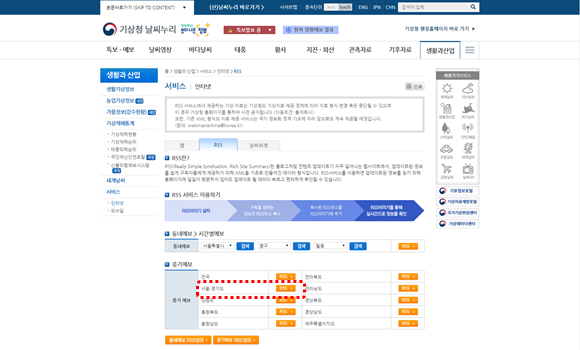


In [64]:
viewfile(Dataset_Path+'weather-RSS.xml')

<?xml version="1.0" encoding="utf-8" ?>
<rss version="2.0">
<channel>
<title>기상청 육상 중기예보</title>
<link>http://www.kma.go.kr/weather/forecast/mid-term_02.jsp</link>
<description>기상청 날씨 웹서비스</description>
<language>ko</language>
<generator>기상청</generator>
<pubDate>2020년 01월 14일 (화)요일 06:00</pubDate>
 <item>
<author>기상청</author>
<category>육상중기예보</category>
<title>서울,경기도 육상 중기예보 - 2020년 01월 14일 (화)요일 06:00 발표</title>
<link>http://www.kma.go.kr/weather/forecast/mid-term_02.jsp</link>
<guid>http://www.kma.go.kr/weather/forecast/mid-term_02.jsp</guid>
<description>
    <header>
        <title>서울,경기도 육상중기예보</title>
        <tm>202001140600</tm>
        <wf><![CDATA[기압골 영향으로 19일에 눈이 오겠고, 그 밖의 기간에는 고기압의 가장자리에 들어 가끔 구름많겠습니다.<br />기온은 평년(최저기온: -9~-5℃, 최고기온: 1~2℃)과 비슷하거나 조금 높겠습니다.<br />강수량은 평년(0~1mm)보다 적겠습니다.<br />서해중부해상의 물결은 0.5~2.0m로 일겠습니다.]]></wf>
    </header>
    <body>
                

        <location wl_ver="3">
                <province>서울ㆍ인천ㆍ경기도</province>
                <city>서울</city

                    <mode>A01</mode>
                    <tmEf>2020-01-24 00:00</tmEf>
                    <wf>흐림</wf>
                    <tmn>-4</tmn>
                    <tmx>2</tmx>
                    <reliability></reliability>
                    <rnSt>30</rnSt>
                </data>


        </location>

        <location wl_ver="3">
                <province>서울ㆍ인천ㆍ경기도</province>
                <city>의정부</city>
                
                <data>
                    <mode>A02</mode>
                    <tmEf>2020-01-17 00:00</tmEf>
                    <wf>흐림</wf>
                    <tmn>-9</tmn>
                    <tmx>4</tmx>
                    <reliability></reliability>
                    <rnSt>30</rnSt>
                </data>

                
                <data>
                    <mode>A02</mode>
                    <tmEf>2020-01-17 12:00</tmEf>
                    <wf>흐림</wf>
                    <tmn>-9</tmn>
                    <tmx>4</tmx>
            

                
                <data>
                    <mode>A02</mode>
                    <tmEf>2020-01-17 12:00</tmEf>
                    <wf>흐림</wf>
                    <tmn>-6</tmn>
                    <tmx>4</tmx>
                    <reliability></reliability>
                    <rnSt>30</rnSt>
                </data>

                
                <data>
                    <mode>A02</mode>
                    <tmEf>2020-01-18 00:00</tmEf>
                    <wf>맑음</wf>
                    <tmn>-6</tmn>
                    <tmx>5</tmx>
                    <reliability></reliability>
                    <rnSt>0</rnSt>
                </data>

                
                <data>
                    <mode>A02</mode>
                    <tmEf>2020-01-18 12:00</tmEf>
                    <wf>맑음</wf>
                    <tmn>-6</tmn>
                    <tmx>5</tmx>
                    <reliability></reliability>
                    <rnSt>0</rnSt>
                </data

### XML 로드하고 시간별 날씨 읽어보기

In [42]:
from xml.etree import ElementTree

# 기상청 정보를 xml 형식으로 파싱
tree = ElementTree.parse(Dataset_Path+'weather-RSS.xml') 

# xml의 root 요소를 추출
root = tree.getroot()

for data in root.findall('channel/item/description/body/location/data'):
    tmEf = data.find('tmEf').text
    wf = data.find('wf').text
    print(tmEf, wf)

2020-01-17 00:00 흐림
2020-01-17 12:00 흐림
2020-01-18 00:00 맑음
2020-01-18 12:00 맑음
2020-01-19 00:00 흐림
2020-01-19 12:00 흐리고 눈
2020-01-20 00:00 맑음
2020-01-20 12:00 맑음
2020-01-21 00:00 흐림
2020-01-21 12:00 흐림
2020-01-22 00:00 흐림
2020-01-23 00:00 흐림
2020-01-24 00:00 흐림
2020-01-17 00:00 흐림
2020-01-17 12:00 흐림
2020-01-18 00:00 맑음
2020-01-18 12:00 맑음
2020-01-19 00:00 흐림
2020-01-19 12:00 흐리고 눈
2020-01-20 00:00 맑음
2020-01-20 12:00 맑음
2020-01-21 00:00 흐림
2020-01-21 12:00 흐림
2020-01-22 00:00 흐림
2020-01-23 00:00 흐림
2020-01-24 00:00 흐림
2020-01-17 00:00 흐림
2020-01-17 12:00 흐림
2020-01-18 00:00 맑음
2020-01-18 12:00 맑음
2020-01-19 00:00 흐림
2020-01-19 12:00 흐리고 눈
2020-01-20 00:00 맑음
2020-01-20 12:00 맑음
2020-01-21 00:00 흐림
2020-01-21 12:00 흐림
2020-01-22 00:00 흐림
2020-01-23 00:00 흐림
2020-01-24 00:00 흐림
2020-01-17 00:00 흐림
2020-01-17 12:00 흐림
2020-01-18 00:00 맑음
2020-01-18 12:00 맑음
2020-01-19 00:00 흐림
2020-01-19 12:00 흐리고 눈
2020-01-20 00:00 맑음
2020-01-20 12:00 맑음
2020-01-21 00:00 흐림
2020-01-21 12:00 흐림
2020-01-